# <u> **Proxy Statements Stakeholder Engagement or Orientation NLP Analysis** </u>

### **Data Analysis Steps:**
- Collect proxy statements from EDGAR or company websites.
- Preprocess text to focus on governance and shareholder proposal sections.
- Apply LDA to identify stakeholder engagement themes (e.g., employee welfare, community outreach).
- Use sentiment analysis to evaluate the tone of stakeholder discussions.
- Track changes in engagement language across years using cosine similarity.

### **Challenges:**
- Stakeholder engagement is often a secondary focus, limiting data volume.
- Governance language is vague, requiring contextual NLP models.
- Limited historical data restricts longitudinal analysis.

### **Example:**
- A proxy statement might mention: “Shareholders propose increased stakeholder engagement through community programs.” NLP can extract “stakeholder engagement” and “community programs,” assessing their governance implications.

### **About the Data used:**
- https://www.sec.gov/Archives/edgar/data/1065088/000110465925042545/tm2424429-2_def14a.htm
- UNITED STATES - SECURITIES AND EXCHANGE COMMISSION - Washington, D.C. 20549​
- SCHEDULE 14A - Proxy Statement Pursuant to Section 14(a) of the Securities - Exchange Act of 1934 (Amendment No.  )
- Ebay Inc. 2025 Annual Proxy Statement

---

## **Importing Packages:**

In [1]:
from MyPackages import *


---

## **Collect proxy statements from EDGAR or company websites:**

In [2]:
soup = web_text('https://www.sec.gov/Archives/edgar/data/1065088/000110465925042545/tm2424429-2_def14a.htm#P4AO')

lst = []

for i in soup.find_all('span'):
    lst.append(i.get_text(strip= True))

for i in range(len(lst)):
    print(i, ' - ', lst[i])

0  -  UNITED STATES
1  -  SECURITIES AND EXCHANGE COMMISSION
2  -  Washington, D.C. 20549
3  -  ​
4  -  
5  -  SCHEDULE 14A
6  -  SCHEDULE 14A
7  -  
8  -  Proxy Statement Pursuant to Section 14(a) of the Securities
9  -  
10  -  Exchange Act of 1934 (Amendment No.  )
11  -  
12  -  Filed by the Registrant   ☒
13  -  
14  -  Filed by a Party other than the Registrant   ☐
15  -  
16  -  Check the appropriate box:
17  -  
18  -  ☐
19  -  Preliminary Proxy Statement
20  -  
21  -  ☐
22  -  CONFIDENTIAL, FOR USE OF THE COMMISSION ONLY (AS PERMITTED BY RULE 14a-6(e)(2))
23  -  
24  -  ☒
25  -  Definitive Proxy Statement
26  -  
27  -  ☐
28  -  Definitive Additional Materials
29  -  
30  -  ☐
31  -  Soliciting Material Under Rule 14a-12
32  -  
33  -  eBay Inc.
34  -  ​
35  -  
36  -  (Name of Registrant as Specified In Its Charter)
37  -  
38  -  
39  -  (Name of Person(s) Filing Proxy Statement, if Other than the Registrant)
40  -  
41  -  Payment of Filing Fee (Check the appropriate box):

In [3]:
df_all = {'text': lst}
df_all = pd.DataFrame(df_all)

> All the text from the Ebay 2025 annual proxy statement html web page has been downloaded and sent to a list. The list is then converted into a dataframe for easier filtering, editing, and analysis.

## **Preprocess text to focus on governance and shareholder proposal sections:**

> There are 7 different sections of the document that must be extracted. These include the corporate governance section, and a total of 6 different proposal sections.

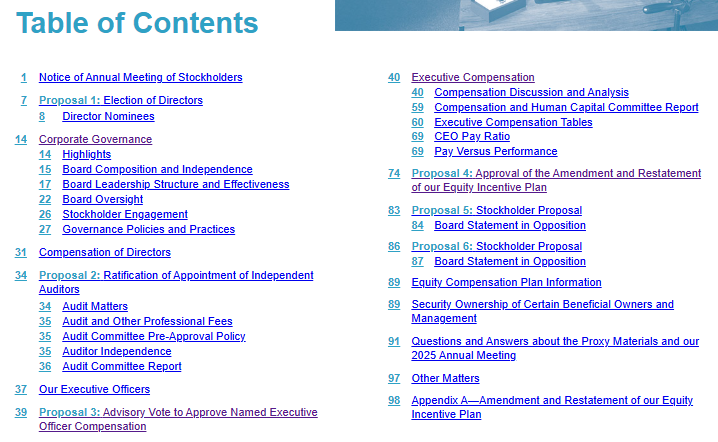

> The first section extracted will be Proposal 1: Election of Directors, and Corporate Governance. The corporate governance section appears right after the proposal 1 section, therefore both these sections will be extracted all at once.

In [4]:
startIndex = df_all[df_all['text'].str.contains('At the Annual Meeting, 11')].index[0]
endIndex = df_all[df_all['text'].str.contains('that would require disclosure under SEC rules.')].index[0]

Prop1_CorporateGov = df_all[startIndex: endIndex]

> The first section has been extracted. The second section is the Proposal 2 section.

In [5]:
startIndex = df_all[df_all['text'].str.contains('The Audit Committee is responsible for the appointment,')].index[0]
endIndex = df_all[df_all['text'].str.contains('for filing with the SEC.')].index[0]

Prop2 = df_all[startIndex: endIndex]

> The second section has been extracted. The third section that must be extracted is the Proposal 3 section.

In [6]:
startIndex = df_all[df_all['text'].str.contains('In accordance with the requirements of Section')].index[0]
endIndex = df_all[df_all['text'].str.contains('occur at the 2026 Annual Meeting of Stockholders.')].index[0]

Prop3 = df_all[startIndex: endIndex]

> The third section has been extracted. Now Proposals 4, 5, and 6 must be extracted as the next section from the proxy statement.

In [7]:
startIndex = df_all[df_all['text'].str.contains('We are seeking stockholder approval to amend and restate ')].index[0]
endIndex = df_all[df_all['text'].str.contains('and objectives and thereby render it unnecessary.')].index[0]

Prop456 = df_all[startIndex: endIndex]

> Each of the Proposal sections (Proposals 1, 2, 3, 4, 5, and 6) have been extracted, and the Corporate Governance section has also been extracted. Now all individual dataframes must be concatinated under one single dataframe. 

In [8]:
df = pd.concat([Prop1_CorporateGov, Prop2, Prop3, Prop456])
df

,text
525,"At the Annual Meeting, 11 directors will be el..."
526,We are seeking the election of 11 directors to...
527,
528,Each of the nominees has consented to serving ...
529,
...,...
3903,
3904,
3905,88
3906,


> This is the dataframe that will be used. However, it is still very messy and must be edited.

In [9]:
newList = []
current = ""

for text in df['text'].tolist():
    current += " " + text

    if text.endswith("."):
        newList.append(current.strip())
        current = ""

df = {'text': newList}
df = pd.DataFrame(df)

> This is the new dataframe that has been created. The problem with the other data text data is that when we parsed the data from an html web page and then into python into a dataframe, many of the sentences were split among many different rows of the list. This for loop gets all the lines of text in a row that do not end with a period and combines them. It re-attatches each sentence of the proxy statement back together. However, there are still some mistakes within the text that we must fix and filter out.

In [10]:
df = df[df['text'].str.len() >= 50]
df['text'].tolist()

['At the Annual Meeting, 11 directors will be elected to serve for a one-year term.',
 'We are seeking the election of 11 directors to our Board. Each of the nominees is currently a member of the Board, and each of the nominees has been elected previously by stockholders, except for Bill Nash, who joined the Board on September\xa018, 2024. Mr.\xa0Nash further enhances the Board’s composition with his significant experience in retail, ecommerce, and technology development. His experience as the CEO of CarMax deepens the knowledge and experience of our Board and will aid its focus on eBay’s sustainable long-term growth.',
 'Each of the nominees has consented to serving and being named as a nominee in this Proxy Statement and to serving as a director if elected. 10 of the 11 nominees are currently independent directors under the listing standards of Nasdaq and our Governance Guidelines of the Board (the “Governance Guidelines”). If elected at the Annual Meeting, each of the nominees will 

> This is the final dataset that will be used for this analysis.

In [11]:
df = df.reset_index()
df = df.drop(labels= 'index', axis= 1)

## **Apply LDA to identify stakeholder engagement themes (e.g., employee welfare, community outreach):**

In [12]:
vector = count_vector(stop_words= 'english')
transformed = vector.fit_transform(df['text'])

> First each word from each line of text from the proxy statement dataframe must be converted to a numerical value.

In [13]:
model = lda(n_components= 5, random_state= 42).fit(transformed)

> This is the Latent Dirichlet Allocation model. It will be extracting 5 different topics from the transformed text which the model is being fit to.

In [14]:
words = vector.get_feature_names_out()
weights = model.components_

> The words have been extracted from the count vectorizer model, and the weights have been extracted from the Latent Dirichlet Allocation model.

In [15]:
topics = {
    'words': words,
    'topic0': weights[0],
    'topic1': weights[1],
    'topic2': weights[2],
    'topic3': weights[3],
    'topic4': weights[4]
}

topics = pd.DataFrame(topics)

> The topic weights for each word have been extracted and put into a dataframe for analysis.

In [16]:
topics[['words', 'topic0']].sort_values(by= 'topic0', ascending= False).head(10)

,words,topic0
1993,risk,40.280806
813,ebay,39.723298
384,board,39.491127
2153,stockholders,32.203640
1417,management,31.271948
1107,governance,30.186844
1758,program,27.246832
2077,share,22.549843
944,executive,21.771197
632,corporate,21.558603


> The first topic of the proxy statement text involves risk, as well as stakeholder engagement language such as board, stockholders, management, governance, program, executive, and lastly corporate. Overall, the first topic of the text is stockholder management and governance, which is clearly identified to be a stakeholder engagement related theme.

In [17]:
topics[['words', 'topic1']].sort_values(by= 'topic1', ascending= False).head(10)

,words,topic1
384,board,127.453866
756,director,112.645780
813,ebay,79.336280
2153,stockholders,60.304485
1936,resignation,57.199905
1454,meeting,38.461024
757,directors,37.683818
1692,policy,33.743774
831,election,33.150336
2373,vote,31.196665


> The second topic of the proxy statement text also involves stakeholder engagement language such as board of directors, stockholder, management resignation, meeting, directors, and policy election votes. Overall, this second topic of the text is board of directors and stockholder policy, which is very clearly identified as a stakeholder engagement theme.

In [18]:
topics[['words', 'topic2']].sort_values(by= 'topic2', ascending= False).head(10)

,words,topic2
384,board,95.281255
963,experience,60.746966
540,compensation,53.957936
534,company,48.989255
944,executive,45.491031
813,ebay,43.410820
2159,strategy,41.689020
1417,management,38.527608
411,business,31.115203
2229,technology,30.598463


> The third topic of the proxy statement involves more stakeholder engagement language such as board, experience, compensation, company, executive, strategy, management, and business. Overall, the third topic of the text is board and executive compensations related to experience, which again is clearly identified to be a stakeholder engagement related theme.

In [19]:
topics[['words', 'topic3']].sort_values(by= 'topic3', ascending= False).head(10)

,words,topic3
320,audit,60.703303
524,committee,56.660091
1496,mr,30.828034
2063,served,26.023034
2066,services,23.153392
1719,president,22.287328
1008,fees,21.181341
534,company,20.482977
1497,ms,19.564392
1805,pwc,19.194340


> The fourth topic of the proxy statement text does involve some stakeholder engagement language such as committee and company president. However, most of the terms such as audit and company service fees, are more related to financial terms. Therefore, the second topic of the text is company audit and service fees, which can be related to stakeholder engagement themes, but is more in line with finance relaed themes.

In [20]:
topics[['words', 'topic4']].sort_values(by= 'topic4', ascending= False).head(10)

,words,topic4
2151,stock,127.367998
2081,shares,115.625281
346,awards,103.194533
1678,plan,83.060975
901,equity,52.503743
344,award,51.194995
1654,performance,49.918423
1545,number,48.291411
1600,outstanding,46.632587
1113,granted,46.163761


> The fifth and final topic of the proxy statement text does involve financial stakeholder engagement language since it is very financial. The words and phrases are stocks and shares awarded, equity plans, awards granted for outstanding performance, and the numbers. The language used can be related to financial stakeholder engagement language. The second topic of the text is stocks and shares awarded.

## **Use sentiment analysis to evaluate the tone of stakeholder discussions:**

In [21]:
finbertOutput = finbert(df['text'].tolist())
finbertOutput = pd.DataFrame(finbertOutput)

df = pd.merge(df, finbertOutput, left_index= True, right_index= True)

df

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,text,label,score
0,"At the Annual Meeting, 11 directors will be el...",neutral,0.944585
1,We are seeking the election of 11 directors to...,positive,0.751178
2,Each of the nominees has consented to serving ...,neutral,0.919536
3,Our bylaws provide that in the event of an unc...,neutral,0.910988
4,• Each nominee has highly relevant professiona...,positive,0.597468
...,...,...,...
302,Our Board Believes that eBay’s Existing Direct...,neutral,0.647185
303,Pursuant to our existing director resignation ...,neutral,0.845292
304,"If any resignation is rejected by the CGNC, th...",neutral,0.831655
305,The Board believes that eBay’s current directo...,negative,0.788370


> The finbert output (sentiment labels and FinBERT's accuracy score) has been received and combined to the dataframe. The sentiments for each and every single line of text can now be viewed.

In [22]:
counts = df['label'].value_counts().reset_index()
counts

,label,count
0,neutral,265
1,positive,30
2,negative,12


In [23]:
df['label'].value_counts(normalize= True).reset_index()

,label,proportion
0,neutral,0.863192
1,positive,0.097720
2,negative,0.039088


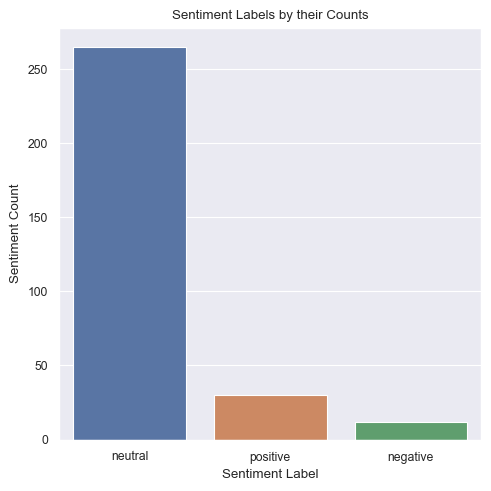

In [24]:
sns.set_theme('paper')
plt.figure(figsize= (5, 5))

sns.barplot(data= counts, x= 'label', y= 'count', hue= 'label')
plt.title('Sentiment Labels by their Counts')
plt.xlabel('Sentiment Label')
plt.ylabel('Sentiment Count')

plt.tight_layout()
plt.show()

> As seen by the graph and the two tables above, the overwhelming majority of the lines of text are neutral. 86% of all lines of text from the extracted Ebay proxy statement are neutral, with a count of 265 lines of text. 10% of the proxy statement text is positive, with a count of 30, and 4% with a count of 12 lines of text are negative.

## **Identifying similar language in text using cosine similarity:**

In [25]:
vector = tf_idf(stop_words= 'english')
transformed = vector.fit_transform(df['text'])

> To use the Cosine Similarity model for determining similar lines of text, the text in the dataframe must be converted to numerical values using the TF-IDF model.

In [26]:
cosineModel = cosine_similarity(transformed)

print(cosineModel)

[[1.         0.17557088 0.45546424 ... 0.11860771 0.07376696 0.03407058]
 [0.17557088 1.         0.2200135  ... 0.03984376 0.10818496 0.0686083 ]
 [0.45546424 0.2200135  1.         ... 0.34606593 0.14076251 0.03772349]
 ...
 [0.11860771 0.03984376 0.34606593 ... 1.         0.27767109 0.13908584]
 [0.07376696 0.10818496 0.14076251 ... 0.27767109 1.         0.26580599]
 [0.03407058 0.0686083  0.03772349 ... 0.13908584 0.26580599 1.        ]]


> The model used to determine how similar each line of text is to another is Cosine Similarity. The model prints out a matrix which shows a percentage of how similar each line of text is to another line of text. For example, the first line of text "At the Annual Meeting, 11 directors will be el..." is 17.56% similar to the second line of text "We are seeking the election of 11 directors to...". The goal with this analysis is to determine which line of text is most similar (has highest percentage) to each line of text in the dataset.

In [27]:
lst = []

for i in range(len(cosineModel)):
    largest = 0
    index = 0
    for k in range(len(cosineModel)):
        if (i != k) and (cosineModel[i][k] >= largest):
            largest = cosineModel[i][k]
            index = k
    lst.append(index)

df['similar text'] = lst
df

,text,label,score,similar text
0,"At the Annual Meeting, 11 directors will be el...",neutral,0.944585,2
1,We are seeking the election of 11 directors to...,positive,0.751178,61
2,Each of the nominees has consented to serving ...,neutral,0.919536,0
3,Our bylaws provide that in the event of an unc...,neutral,0.910988,302
4,• Each nominee has highly relevant professiona...,positive,0.597468,38
...,...,...,...,...
302,Our Board Believes that eBay’s Existing Direct...,neutral,0.647185,125
303,Pursuant to our existing director resignation ...,neutral,0.845292,127
304,"If any resignation is rejected by the CGNC, th...",neutral,0.831655,124
305,The Board believes that eBay’s current directo...,negative,0.788370,301


> With this nested for loop, the index of the similar text for each line of text has been found.

In [28]:
counts = df['similar text'].value_counts().reset_index().head(20).sort_values(by= 'count', ascending= False)
counts

,similar text,count
0,106,7
1,3,6
2,73,5
3,276,5
4,193,5
5,38,4
6,154,4
7,294,4
8,40,4
9,83,3


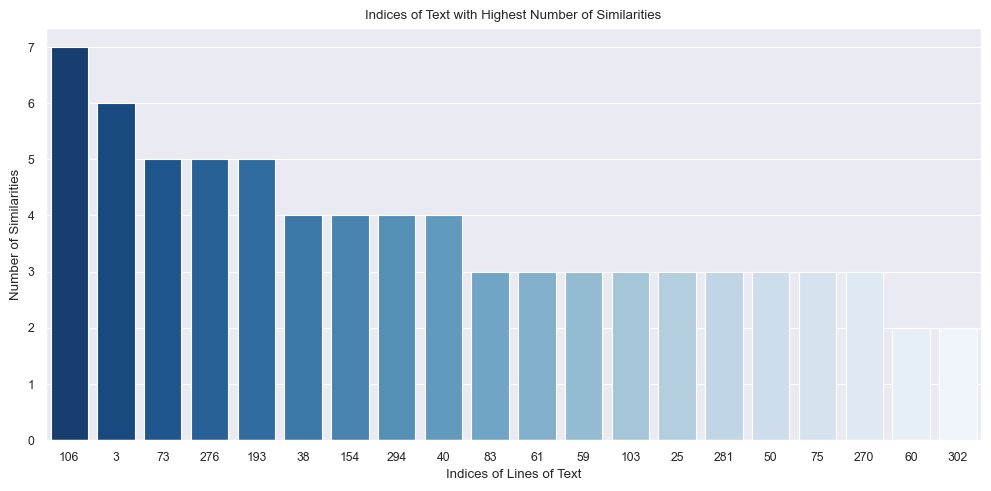

In [29]:
sns.set_theme('paper')
plt.figure(figsize= (10, 5))

sns.barplot(data= counts, x= 'similar text', y= 'count', order= counts['similar text'].tolist(), palette= 'Blues_r')
plt.title('Indices of Text with Highest Number of Similarities')
plt.xlabel('Indices of Lines of Text')
plt.ylabel('Number of Similarities')

plt.tight_layout()
plt.show()

> The line of text index which is most similar to the highest number of other lines of text is 106, with a total number of similarities at 7. The index with the second highest number of similarities is 3, with a count at 6 similar lines of text.

In [30]:
df[df['text'].index == 106]

,text,label,score,similar text
106,eBay Impact: Our Focus on Sustainable Commerce...,neutral,0.852531,110


> This is the record of the dataframe that contains the line of text which is most similar to a total of 7 other lines of text. It is labeled as neutral by the FinBERT model, and the index of the line of text it itself is most similar to is at 110. 
>
> NOTE: The similarity count determined by the graph and the table above specifies the number of times text index 106 is referenced in the "similar text" column. It is the number of how many OTHER lines of text are similar to index 106, it is NOT saying how many lines of text index 106 is similar to. Index 106 itself is only similar to one other line of text, as is all other lines of text. But 7 of those lines of text reference index 106.

In [31]:
df[df['text'].index == 106]['text'].tolist()

['eBay Impact: Our Focus on Sustainable Commerce and Economic Empowerment  eBay is a global commerce leader that connects people and builds communities to create economic opportunity for all. eBay’s Impact team supports this goal by focusing its efforts on several key areas identified in our sustainability materiality assessment, including Economic Opportunity, Sustainable Commerce, Culture & Workforce and maintaining a Trusted Marketplace. Our materiality assessment is facilitated by an outside advisor and updated every three\xa0years to ensure that our Impact programs continue to reflect the issues we believe to be the most important for eBay and its business. As noted above, the CGNC receives periodic updates on eBay sustainability initiatives, reporting, investor feedback and third-party ratings.']

> The index 106 text is "eBay Impact: Our Focus on Sustainable Commerce and Economic Empowerment  eBay is a global commerce leader that connects people and builds communities to create economic opportunity for all. eBay’s Impact team supports this goal by focusing its efforts on several key areas identified in our sustainability materiality assessment, including Economic Opportunity, Sustainable Commerce, Culture & Workforce and maintaining a Trusted Marketplace. Our materiality assessment is facilitated by an outside advisor and updated every three\xa0years to ensure that our Impact programs continue to reflect the issues we believe to be the most important for eBay and its business. As noted above, the CGNC receives periodic updates on eBay sustainability initiatives, reporting, investor feedback and third-party ratings." As you can read, this is simply a general statement about eBay's impact on commerce, the economy, and communities.